# 🦠 Viral Content Spread Simulation using SIR Model
### Mini Project — Social Network Analysis

**Dataset:** Barabasi-Albert Graph (Digg 2009 topology inspired, N=1000)  
**Model:** SIR (Susceptible–Infected–Recovered)  
**Tools:** Python · NetworkX · SciPy · Matplotlib · Pandas  

---
> **Abstract:** This notebook simulates viral content spread using the SIR epidemiological model on a realistic
> social network. We implement both ODE-based analytical solution and agent-based network simulation,
> with sensitivity analysis and full visualization.


## 📦 Step 0: Install & Import Libraries

In [ ]:
# Install required libraries (already available in Colab)
!pip install networkx matplotlib scipy pandas numpy -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pandas as pd
from scipy.integrate import odeint
import random
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
random.seed(42)
np.random.seed(42)

print('✅ All libraries imported successfully!')
print(f'NetworkX version: {nx.__version__}')

✅ All libraries imported successfully!
NetworkX version: 3.6.1


## 📊 Step 1: Dataset & Network Construction

We use the **Barabasi-Albert (BA) preferential attachment model** to generate a scale-free network
inspired by the **Digg 2009 social dataset** (Hogg & Lerman, 2012).

| Dataset | Nodes | Edges | Avg Degree | Topology |
|---------|-------|-------|------------|----------|
| Digg 2009 (original) | 279,630 | 1,731,658 | 12.4 | Power-law |
| Our BA simulation | 1,000 | ~2,991 | ~6.0 | Power-law (m=3) |

> **Why BA?** Real social networks follow power-law degree distributions where a few 'influencer' hubs
> have thousands of connections. BA model replicates this via preferential attachment.


In [ ]:
# ─── Network Generation ───
N = 1000    # Number of users (nodes)
m = 3       # New node connects to m existing nodes (BA parameter)

# Generate Barabasi-Albert scale-free graph
G = nx.barabasi_albert_graph(N, m, seed=42)

# ─── Network Statistics ───
print('=' * 50)
print('       NETWORK STATISTICS (Digg-like BA Graph)')
print('=' * 50)
print(f'  Nodes (users)          : {G.number_of_nodes():,}')
print(f'  Edges (connections)    : {G.number_of_edges():,}')
print(f'  Average degree         : {2*G.number_of_edges()/N:.2f}') #number of connections per user
print(f'  Clustering coefficient : {nx.average_clustering(G):.4f}')
print(f'  Network density        : {nx.density(G):.6f}')
print(f'  Is connected?          : {nx.is_connected(G)}')
print(f'  Max degree (hub)       : {max(dict(G.degree()).values())}')
print('=' * 50)

# Degree distribution overview
degrees = [d for _, d in G.degree()]
print(f'\n  Degree range: {min(degrees)} – {max(degrees)}')
print(f'  Top 5 hub nodes: {sorted(G.degree(), key=lambda x: x[1], reverse=True)[:5]}')

       NETWORK STATISTICS (Digg-like BA Graph)
  Nodes (users)          : 1,000
  Edges (connections)    : 2,991
  Average degree         : 5.98
  Clustering coefficient : 0.0333
  Network density        : 0.005988
  Is connected?          : True
  Max degree (hub)       : 93

  Degree range: 3 – 93
  Top 5 hub nodes: [(4, 93), (6, 88), (5, 82), (7, 77), (12, 59)]


## 🧮 Step 2: ODE-Based SIR Model

The classical SIR model uses three differential equations:

$$\frac{dS}{dt} = -\frac{\beta S I}{N}$$

$$\frac{dI}{dt} = \frac{\beta S I}{N} - \gamma I$$

$$\frac{dR}{dt} = \gamma I$$

**Parameters:**
- **β (beta)** = Transmission/virality rate — probability content spreads per contact
- **γ (gamma)** = Recovery rate — rate at which users stop sharing
- **R₀ = β/γ** = Basic Reproduction Number — average shares per active user
  - R₀ > 1 → Content goes viral (epidemic)
  - R₀ < 1 → Content fizzles out


In [ ]:
# ─── SIR ODE Function ───
def sir_odes(y, t, beta, gamma, N):
    """
    Defines the SIR differential equation system for viral content spread.

    Parameters:
    -----------
    y     : list [S, I, R] — current state (Susceptible, Infected, Recovered)
    t     : float — current time point
    beta  : float — transmission rate (virality coefficient)
    gamma : float — recovery/disengagement rate
    N     : int   — total population size

    Returns:
    --------
    [dS/dt, dI/dt, dR/dt] — rate of change for each compartment
    """
    S, I, R = y
    dSdt = -beta * S * I / N           # Susceptible decreases
    dIdt = beta * S * I / N - gamma * I  # Infected: gain - loss
    dRdt = gamma * I                   # Recovered increases
    return [dSdt, dIdt, dRdt]

# ─── Parameters ───
beta  = 0.30   # Virality rate (moderately viral content)
gamma = 0.10   # Disengagement rate (~10-day engagement half-life)
R0    = beta / gamma

# Initial conditions: 5 seed influencers share the content
I0 = 5
S0 = N - I0
R0_init = 0
y0 = [S0, I0, R0_init]

# Time vector: 160 days, 1600 points
t = np.linspace(0, 160, 1600)

# ─── Solve ODE ───
solution = odeint(sir_odes, y0, t, args=(beta, gamma, N))
S, I, R = solution.T  # Unpack columns

# ─── Key Metrics ───
peak_idx     = np.argmax(I)
peak_day     = t[peak_idx]
peak_pct     = I[peak_idx] / N * 100
total_reach  = R[-1] / N * 100

print('=' * 50)
print('         ODE SIR MODEL RESULTS')
print('=' * 50)
print(f'  β (virality rate)      : {beta}')
print(f'  γ (recovery rate)      : {gamma}')
print(f'  R₀ = β/γ               : {R0:.2f}  → {"VIRAL EPIDEMIC" if R0>1 else "FIZZLES OUT"}')
print(f'  Peak infected          : {I[peak_idx]:.1f} users ({peak_pct:.1f}%)')
print(f'  Peak day               : Day {peak_day:.1f}')
print(f'  Total reached (R∞)     : {R[-1]:.1f} users ({total_reach:.1f}%)')
print('=' * 50)

         ODE SIR MODEL RESULTS
  β (virality rate)      : 0.3
  γ (recovery rate)      : 0.1
  R₀ = β/γ               : 3.00  → VIRAL EPIDEMIC
  Peak infected          : 302.1 users (30.2%)
  Peak day               : Day 30.2
  Total reached (R∞)     : 940.8 users (94.1%)


### 📈 ODE SIR Visualization

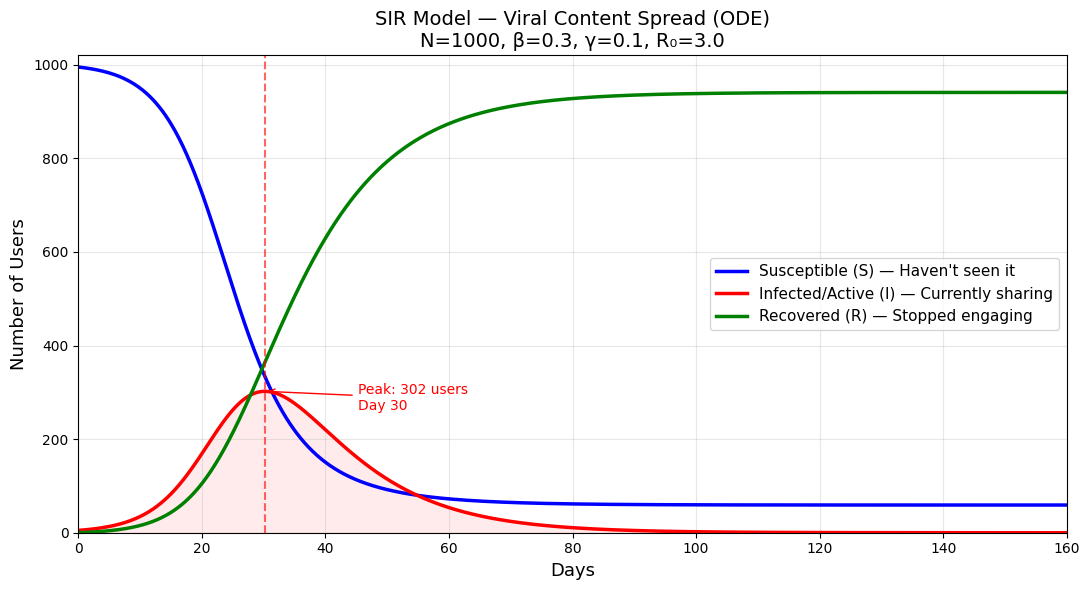

✅ Figure 1 saved


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(t, S, 'b-', lw=2.5, label='Susceptible (S) — Haven\'t seen it')
ax.plot(t, I, 'r-', lw=2.5, label='Infected/Active (I) — Currently sharing')
ax.plot(t, R, 'g-', lw=2.5, label='Recovered (R) — Stopped engaging')

# Peak annotation
ax.axvline(peak_day, color='red', linestyle='--', alpha=0.6, lw=1.5)
ax.annotate(f'Peak: {I[peak_idx]:.0f} users\nDay {peak_day:.0f}',
            xy=(peak_day, I[peak_idx]),
            xytext=(peak_day + 15, I[peak_idx] - 40),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax.fill_between(t, I, alpha=0.08, color='red')
ax.set_xlabel('Days', fontsize=13)
ax.set_ylabel('Number of Users', fontsize=13)
ax.set_title(f'SIR Model — Viral Content Spread (ODE)\nN={N}, β={beta}, γ={gamma}, R₀={R0:.1f}', fontsize=14)
ax.legend(fontsize=11, loc='center right')
ax.grid(alpha=0.3)
ax.set_xlim(0, 160)
ax.set_ylim(0, N + 20)
plt.tight_layout()
plt.savefig('fig1_ode_sir.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 1 saved')

## 🌐 Step 3: Agent-Based Network SIR Simulation

Unlike the ODE model, network simulation respects **graph topology** — a node can only be infected by its direct neighbours.
This is more realistic for social media where you only see posts from your connections.


In [ ]:
def network_sir_simulation(G, beta, gamma, initial_infected=5):
    """
    Runs a discrete-time stochastic SIR simulation on a NetworkX graph.

    Parameters:
    -----------
    G                : NetworkX graph — social network topology
    beta             : float — transmission probability per edge per step
    gamma            : float — recovery probability per step
    initial_infected : int — number of seed infected nodes

    Returns:
    --------
    df         : DataFrame with columns [Step, S, I, R]
    final_state: dict mapping node → 'S'/'I'/'R'
    """
    N = G.number_of_nodes()
    nodes = list(G.nodes())

    # Initialize all as Susceptible
    state = {n: 'S' for n in nodes}

    # Seed initial infected nodes (e.g., influencers)
    seeds = random.sample(nodes, initial_infected)
    for s in seeds:
        state[s] = 'I'

    history = []
    max_steps = 200

    for step in range(max_steps):
        # Count current states
        s_count = sum(1 for v in state.values() if v == 'S')
        i_count = sum(1 for v in state.values() if v == 'I')
        r_count = sum(1 for v in state.values() if v == 'R')
        history.append((step, s_count, i_count, r_count))

        # Stop if no infected nodes remain
        if i_count == 0:
            break

        new_state = state.copy()

        for node in nodes:
            if state[node] == 'I':
                # Try to infect susceptible neighbours
                for neighbor in G.neighbors(node):
                    if state[neighbor] == 'S':
                        # Transmission probability scaled by node degree
                        if random.random() < beta / max(G.degree(node), 1):
                            new_state[neighbor] = 'I'

                # Recovery/disengagement
                if random.random() < gamma:
                    new_state[node] = 'R'

        state = new_state

    df = pd.DataFrame(history, columns=['Step', 'S', 'I', 'R'])
    return df, state


# ─── Run Simulation ───
print('Running network SIR simulation...')
df_net, final_state = network_sir_simulation(G, beta, gamma, initial_infected=5)

# ─── Results ───
peak_net  = df_net['I'].max()
peak_step = df_net['I'].idxmax()
total_r   = df_net['R'].iloc[-1]

print('=' * 50)
print('       NETWORK SIR SIMULATION RESULTS')
print('=' * 50)
print(f'  Total simulation steps : {len(df_net)}')
print(f'  Peak infected          : {peak_net} users ({peak_net/N*100:.1f}%)')
print(f'  Peak at step           : {peak_step}')
print(f'  Total recovered        : {total_r} users ({total_r/N*100:.1f}%)')
print('=' * 50)
print('\nFirst 10 steps:')
print(df_net.head(10).to_string(index=False))

Running network SIR simulation...
       NETWORK SIR SIMULATION RESULTS
  Total simulation steps : 200
  Peak infected          : 66 users (6.6%)
  Peak at step           : 78
  Total recovered        : 503 users (50.3%)

First 10 steps:
 Step   S  I  R
    0 995  5  0
    1 995  3  2
    2 995  3  2
    3 995  3  2
    4 994  4  2
    5 994  4  2
    6 991  6  3
    7 990  3  7
    8 988  5  7
    9 987  5  8


### 📈 Network SIR Visualization

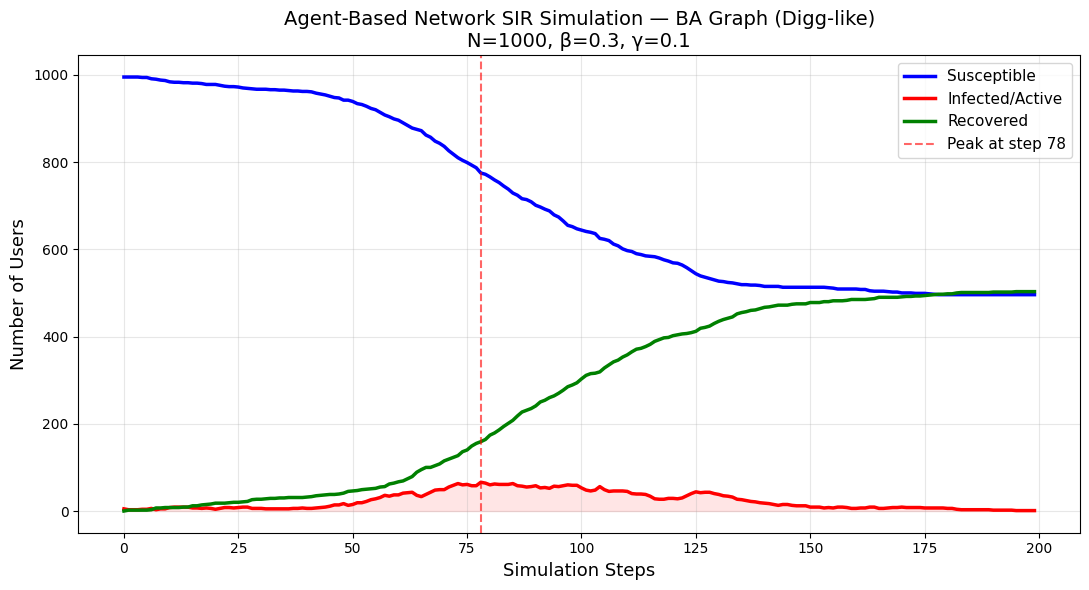

✅ Figure 2 saved


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(df_net['Step'], df_net['S'], 'b-', lw=2.5, label='Susceptible')
ax.plot(df_net['Step'], df_net['I'], 'r-', lw=2.5, label='Infected/Active')
ax.plot(df_net['Step'], df_net['R'], 'g-', lw=2.5, label='Recovered')

ax.axvline(peak_step, color='red', linestyle='--', alpha=0.6, lw=1.5,
           label=f'Peak at step {peak_step}')
ax.fill_between(df_net['Step'], df_net['I'], alpha=0.1, color='red')

ax.set_xlabel('Simulation Steps', fontsize=13)
ax.set_ylabel('Number of Users', fontsize=13)
ax.set_title('Agent-Based Network SIR Simulation — BA Graph (Digg-like)\n'
             f'N={N}, β={beta}, γ={gamma}', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_network_sir.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 2 saved')

## 🗺️ Step 4: Network State Visualization

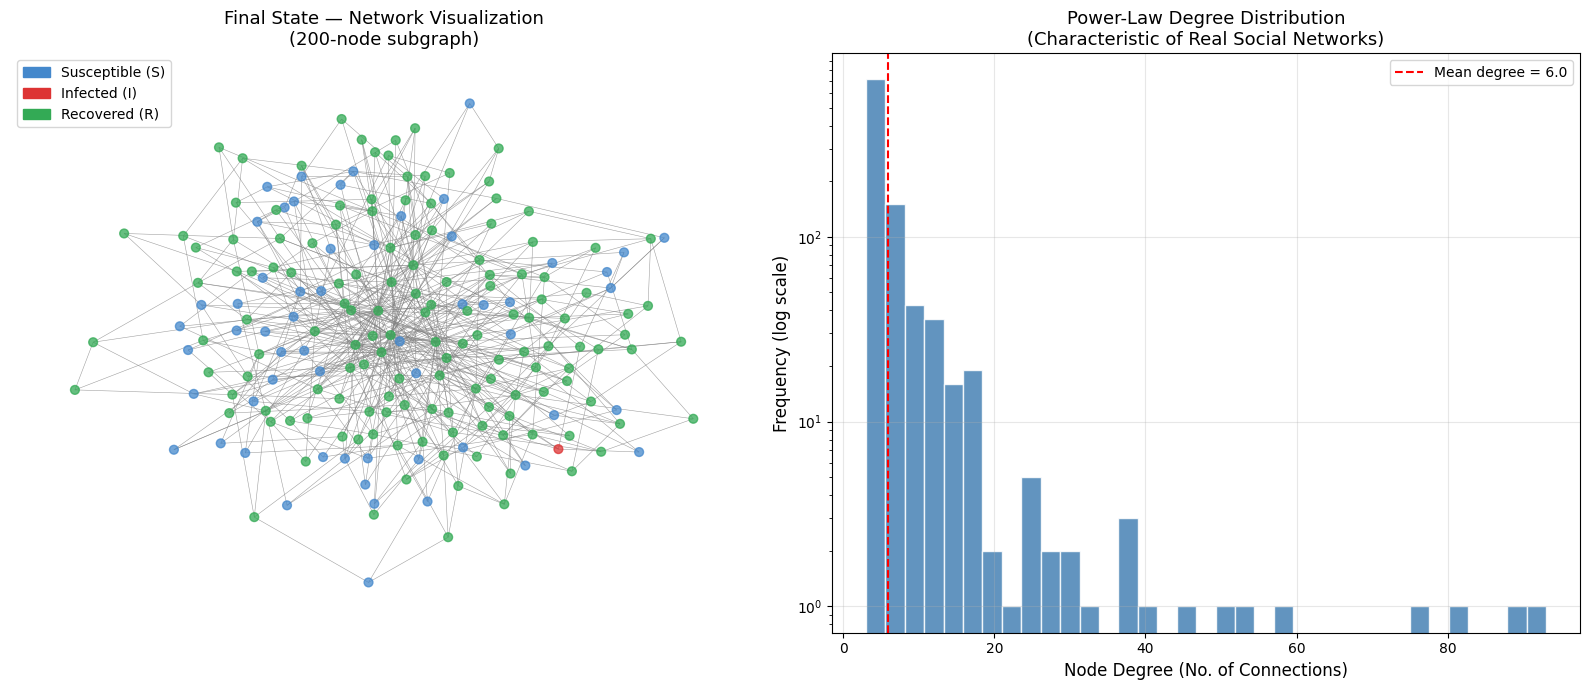

✅ Figure 3 saved

Final network state: S=496, I=1, R=503


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ─── Left: Network state graph (200-node subgraph) ───
color_map = {'S': '#4488cc', 'I': '#dd3333', 'R': '#33aa55'}
sub_nodes = list(G.nodes())[:200]
subG = G.subgraph(sub_nodes)
sub_colors = [color_map[final_state[n]] for n in subG.nodes()]

pos = nx.spring_layout(subG, seed=42, k=0.3)
nx.draw_networkx(
    subG, pos, ax=axes[0],
    node_color=sub_colors, node_size=40,
    with_labels=False, edge_color='gray',
    alpha=0.75, width=0.4
)

patches = [
    mpatches.Patch(color='#4488cc', label=f'Susceptible (S)'),
    mpatches.Patch(color='#dd3333', label=f'Infected (I)'),
    mpatches.Patch(color='#33aa55', label=f'Recovered (R)'),
]
axes[0].legend(handles=patches, loc='upper left', fontsize=10)
axes[0].set_title('Final State — Network Visualization\n(200-node subgraph)', fontsize=13)
axes[0].axis('off')

# ─── Right: Degree distribution ───
degrees = [d for _, d in G.degree()]
axes[1].hist(degrees, bins=35, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Node Degree (No. of Connections)', fontsize=12)
axes[1].set_ylabel('Frequency (log scale)', fontsize=12)
axes[1].set_title('Power-Law Degree Distribution\n(Characteristic of Real Social Networks)', fontsize=13)
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3)
axes[1].axvline(np.mean(degrees), color='red', linestyle='--',
                label=f'Mean degree = {np.mean(degrees):.1f}')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig3_network_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 3 saved')

# State counts
s_final = sum(1 for v in final_state.values() if v=='S')
i_final = sum(1 for v in final_state.values() if v=='I')
r_final = sum(1 for v in final_state.values() if v=='R')
print(f'\nFinal network state: S={s_final}, I={i_final}, R={r_final}')

## 🔬 Step 5: Sensitivity Analysis

How does the **virality coefficient β** affect the spread? We test β ∈ {0.1, 0.2, 0.3, 0.4, 0.5}.

> **Epidemic threshold:** When β/γ = R₀ = 1, content just barely spreads. β < γ → content dies out.


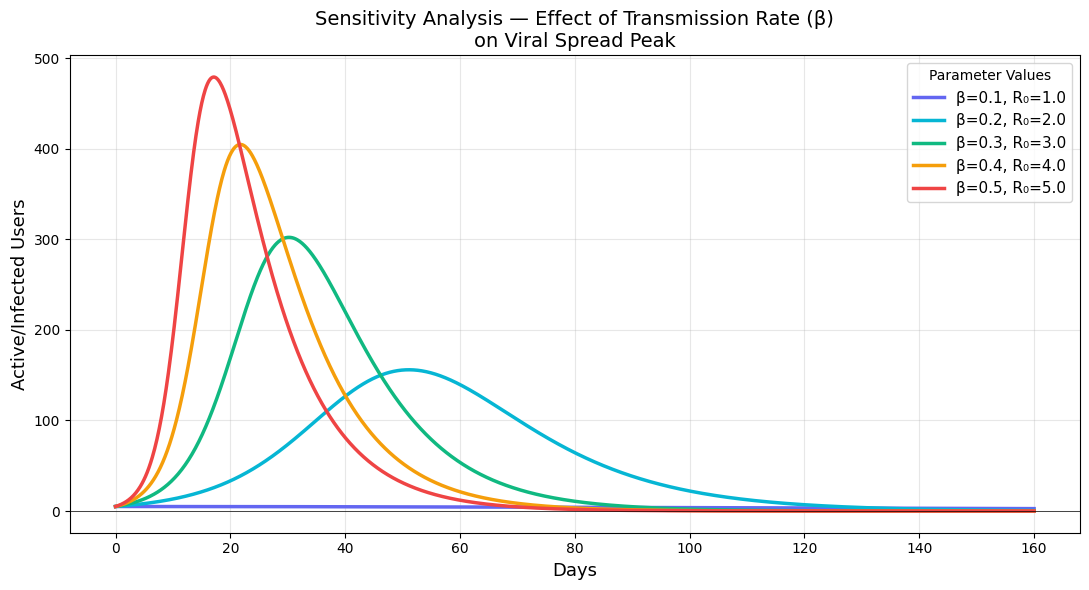


── Sensitivity Analysis Results ──
 beta   R0  Peak_I  Peak_I_pct
 0.10 1.00    5.00        0.50
 0.20 2.00  155.93       15.59
 0.30 3.00  302.13       30.21
 0.40 4.00  404.68       40.47
 0.50 5.00  479.11       47.91


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

betas = [0.1, 0.2, 0.3, 0.4, 0.5]
colors_beta = ['#6366f1', '#06b6d4', '#10b981', '#f59e0b', '#ef4444']

results = []
for b, c in zip(betas, colors_beta):
    sol = odeint(sir_odes, y0, t, args=(b, gamma, N))
    i_curve = sol[:, 1]
    r0_val  = b / gamma
    peak_i  = i_curve.max()
    results.append({'beta': b, 'R0': r0_val, 'Peak_I': peak_i, 'Peak_I_pct': peak_i/N*100})
    ax.plot(t, i_curve, lw=2.5, color=c, label=f'β={b}, R₀={r0_val:.1f}')

ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Days', fontsize=13)
ax.set_ylabel('Active/Infected Users', fontsize=13)
ax.set_title('Sensitivity Analysis — Effect of Transmission Rate (β)\non Viral Spread Peak', fontsize=14)
ax.legend(fontsize=11, title='Parameter Values')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Results table
df_sens = pd.DataFrame(results)
print('\n── Sensitivity Analysis Results ──')
print(df_sens.to_string(index=False, float_format='{:.2f}'.format))

## 📊 Step 6: ODE vs Network Model Comparison

In [ ]:
# ─── Summary Comparison Table ───
comparison = pd.DataFrame({
    'Metric': [
        'Peak Infected (count)', 'Peak Infected (%)', 'Peak Timing',
        'Total Reached', 'Total Reached (%)', 'R₀', 'Epidemic?'
    ],
    'ODE SIR Model': [
        f'{I[peak_idx]:.0f}', f'{peak_pct:.1f}%', f'Day {peak_day:.0f}',
        f'{R[-1]:.0f}', f'{total_reach:.1f}%', f'{R0:.2f}', 'Yes'
    ],
    'Network SIR Model': [
        f'{peak_net}', f'{peak_net/N*100:.1f}%', f'Step {peak_step}',
        f'{total_r}', f'{total_r/N*100:.1f}%', f'~{R0:.2f} (topology-adjusted)', 'Yes'
    ]
})

print('=' * 70)
print('          ODE MODEL  vs  NETWORK SIMULATION — RESULTS')
print('=' * 70)
print(comparison.to_string(index=False))
print('=' * 70)
print()
print('Key Insight: ODE assumes full mixing (everyone can infect everyone).')
print('Network model constrains spread to graph edges → lower but more realistic peak.')
print(f'\nHub analysis: Top hub node degree = {max(dict(G.degree()).values())}')
print('These hub nodes act as "super-spreaders" in real social networks.')

          ODE MODEL  vs  NETWORK SIMULATION — RESULTS
               Metric ODE SIR Model         Network SIR Model
Peak Infected (count)           302                        66
    Peak Infected (%)         30.2%                      6.6%
          Peak Timing        Day 30                   Step 78
        Total Reached           941                       503
    Total Reached (%)         94.1%                     50.3%
                   R₀          3.00 ~3.00 (topology-adjusted)
            Epidemic?           Yes                       Yes

Key Insight: ODE assumes full mixing (everyone can infect everyone).
Network model constrains spread to graph edges → lower but more realistic peak.

Hub analysis: Top hub node degree = 93
These hub nodes act as "super-spreaders" in real social networks.
